In [1]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel, RFECV
from scipy.stats import uniform, loguniform
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from tqdm import tqdm
from sklearn.compose import TransformedTargetRegressor

In [2]:
def fit_and_evaluate(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    return r2_train, r2_test

def comparison_plot(res):
    res_sorted = res.sort_values('Test R2', ascending=False)
    df_melted = res_sorted.melt(id_vars='Model',
                                value_vars=['Train R2', 'Test R2'],
                                var_name='Metric',
                                value_name='Score')

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

    plt.title('Порівняння ефективності моделей (Train vs Test)', fontsize=16, pad=20)
    plt.ylabel('R2 Score (Коефіцієнт детермінації)', fontsize=12)
    plt.xlabel('Модель', fontsize=12)
    plt.ylim(0, 1.1)

    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    plt.legend(title='Вибірка', loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.xticks(rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

In [3]:
df = pd.read_csv("data/prepared_data.csv")
target_column = "Гострота зору некорегована далека відстань"
df = df.dropna(subset=[target_column]).reset_index(drop=True)

groups = df['Пацієнт']

x = df.drop(columns=[target_column])
y = df[target_column]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups=groups))

x_train = x.iloc[train_idx].copy()
x_test = x.iloc[test_idx].copy()

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

x_train.drop(columns=['Пацієнт'], inplace=True)
x_test.drop(columns=['Пацієнт'], inplace=True)

gkf = GroupKFold(n_splits=5)

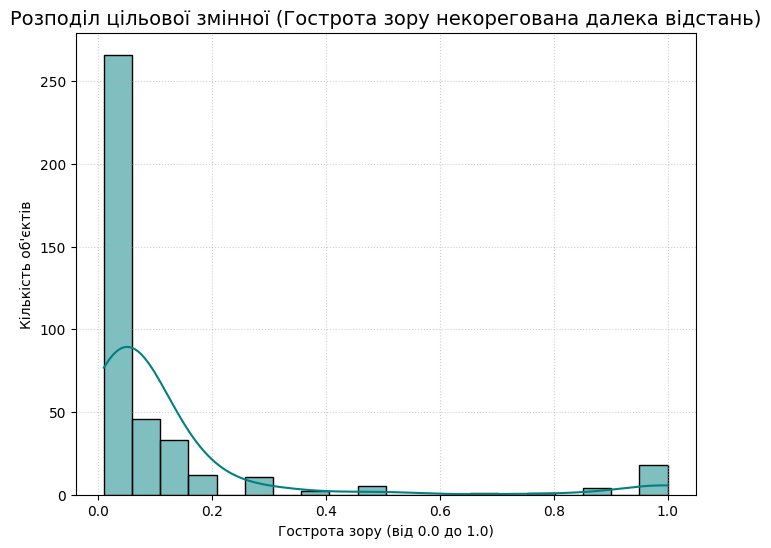

In [4]:
plt.figure(figsize=(8, 6))
sns.histplot(y, bins=20, kde=True, color='teal')
plt.title('Розподіл цільової змінної (Гострота зору некорегована далека відстань)', fontsize=14)
plt.xlabel('Гострота зору (від 0.0 до 1.0)')
plt.ylabel("Кількість об'єктів")
plt.grid(True, linestyle=':', alpha=0.6)

Аналіз розподілу цільової змінної показує, що дані не є збалансованими. Більшість об'єктів мають низьку гостроту зору, що є типовим для клінічної вибірки патологій.

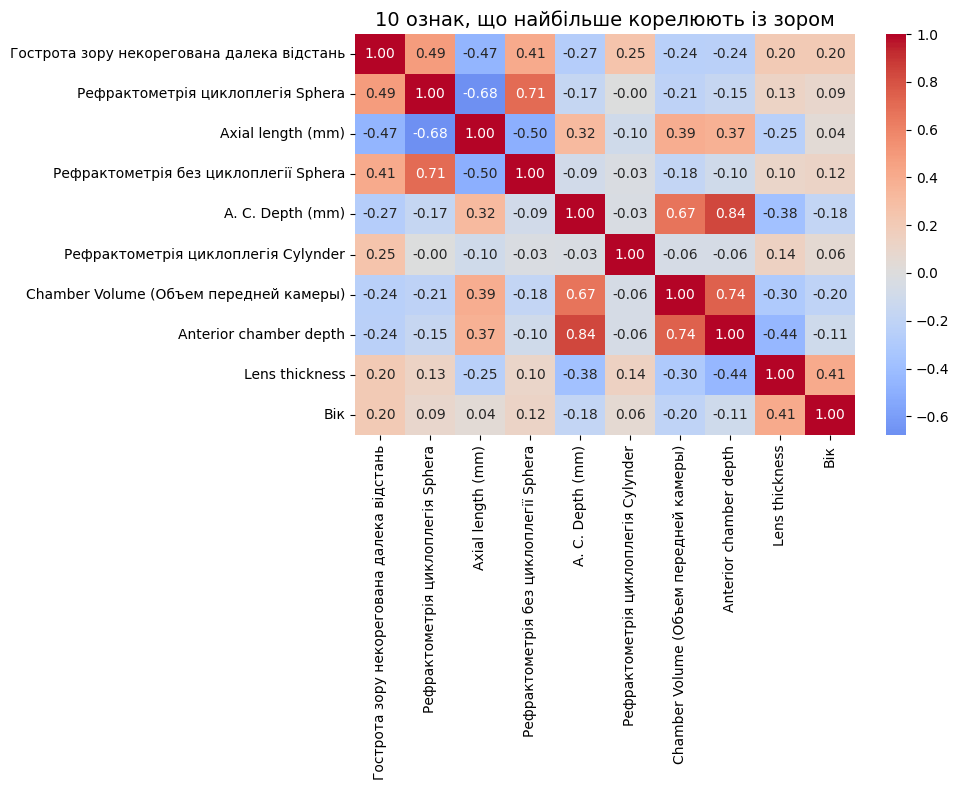

In [5]:
correlations = df.corr()[target_column].abs().sort_values(ascending=False)
top_features = correlations.head(10).index
top_corr_matrix = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('10 ознак, що найбільше корелюють із зором', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state=42))
])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(elastic_pipe, x_train, y_train, x_test, y_test)

print("ElasticNet:")
print(f"   Train R2: {r2_train_elastic:.4f}")
print(f"   Test R2: {r2_test_elastic:.4f}")

ElasticNet:
   Train R2: 0.0000
   Test R2: -0.0244


In [7]:
grid = {
    'model__alpha': loguniform(1e-4, 100),
    'model__l1_ratio': uniform(0, 1),
    'model__max_iter': [1000, 2000, 5000]
}

elastic_random = RandomizedSearchCV(
    estimator=elastic_pipe,
    param_distributions=grid,
    n_iter=100,
    scoring='r2',
    cv=gkf,
    verbose=1,
    random_state=42,
    return_train_score=True
)

elastic_random.fit(x_train, y_train, groups=groups_train)

best_elastic_pipe = elastic_random.best_estimator_
r2_train_elastic, r2_test_elastic = fit_and_evaluate(best_elastic_pipe, x_train, y_train, x_test, y_test)

print("ElasticNet:")
print(f"   Train R2: {r2_train_elastic:.4f}")
print(f"   Test R2: {r2_test_elastic:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


C:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.223e+00, tolerance: 1.170e-03
  model = cd_fast.enet_coordinate_descent(
C:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.304e-01, tolerance: 1.060e-03
  model = cd_fast.enet_coordinate_descent(
C:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.611e-01, tolerance: 1.194e-03
  model = cd_fast.enet_

ElasticNet:
   Train R2: 0.3283
   Test R2: 0.2956


In [8]:
cv_results_df = pd.DataFrame(elastic_random.cv_results_)
cv_results_df['score_diff'] = cv_results_df['mean_train_score'] - cv_results_df['mean_test_score']

columns_to_keep = ['rank_test_score', 'mean_test_score', 'mean_train_score', 'score_diff', 'params']

cv_summary = cv_results_df[columns_to_keep].sort_values(by='rank_test_score')

display(cv_summary.head(5))

,rank_test_score,mean_test_score,mean_train_score,score_diff,params
85,1,0.248728,0.351682,0.102955,"{'model__alpha': 0.09017915528354478, 'model__..."
20,2,0.245258,0.332826,0.087568,"{'model__alpha': 0.02349099519372942, 'model__..."
10,3,0.242537,0.348318,0.105781,"{'model__alpha': 0.01971387269004537, 'model__..."
92,4,0.237770,0.360573,0.122803,"{'model__alpha': 0.020444965009175222, 'model_..."
0,5,0.234592,0.365199,0.130607,"{'model__alpha': 0.017670169402947963, 'model_..."


In [9]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

r2_train_rf, r2_test_rf = fit_and_evaluate(rf_pipe, x_train, y_train, x_test, y_test)

print("Random forest:")
print(f"   Train R2: {r2_train_rf:.4f}")
print(f"   Test R2: {r2_test_rf:.4f}")

Random forest:
   Train R2: 0.9635
   Test R2: 0.6123


In [10]:
grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [None, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt', 0.5]
}

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_random = RandomizedSearchCV(estimator=rf_pipe,
                               param_distributions=grid,
                               n_iter=50,
                               cv=gkf,
                               verbose=1,
                               scoring='r2',
                               random_state=42, return_train_score=True)

rf_random.fit(x_train, y_train, groups=groups_train)
best_rf_pipe = rf_random.best_estimator_

r2_train_rf, r2_test_rf = fit_and_evaluate(best_rf_pipe, x_train, y_train, x_test, y_test)

print("Random forest:")
print(f"   Train R2: {r2_train_rf:.4f}")
print(f"   Test R2: {r2_test_rf:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Random forest:
   Train R2: 0.8937
   Test R2: 0.5931


In [15]:
cv_results_df = pd.DataFrame(rf_random.cv_results_)
cv_results_df['score_diff'] = cv_results_df['mean_train_score'] - cv_results_df['mean_test_score']

columns_to_keep = ['rank_test_score', 'mean_test_score', 'mean_train_score', 'score_diff', 'params']

cv_summary = cv_results_df[columns_to_keep].sort_values(by='rank_test_score')

display(cv_summary.head(5))

,rank_test_score,mean_test_score,mean_train_score,score_diff,params
39,1,0.649038,0.891702,0.242664,"{'model__n_estimators': 200, 'model__min_sampl..."
15,2,0.646924,0.887796,0.240872,"{'model__n_estimators': 500, 'model__min_sampl..."
29,3,0.639011,0.900035,0.261024,"{'model__n_estimators': 500, 'model__min_sampl..."
16,3,0.639011,0.900035,0.261024,"{'model__n_estimators': 500, 'model__min_sampl..."
40,5,0.637674,0.902187,0.264513,"{'model__n_estimators': 200, 'model__min_sampl..."


In [12]:
nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=20000, random_state=42))
])

r2_train_nn, r2_test_nn = fit_and_evaluate(nn_pipe, x_train, y_train, x_test, y_test)

print(f"Neural network:")
print(f"   Train R2: {r2_train_nn:.4f}")
print(f"   Val R2: {r2_test_nn:.4f}")

Neural network:
   Train R2: 0.9610
   Val R2: 0.0727


In [13]:
grid = {
    'model__hidden_layer_sizes': [(30,), (50,), (100,), (30, 15), (50, 25), (100, 50)],
    'model__activation': ['relu', 'tanh', 'logistic'],
    'model__solver': ['lbfgs', 'adam'],
    'model__alpha': loguniform(1e-5, 1e-1),
    'model__learning_rate_init': loguniform(1e-4, 1e-2)
}

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(max_iter=20000, random_state=42))
])

nn_random = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=grid,
    n_iter=50,
    scoring='r2',
    cv=gkf,
    verbose=1,
    random_state=42,
    return_train_score=True
)

nn_random.fit(x_train, y_train, groups=groups_train)

best_nn_pipe = nn_random.best_estimator_

r2_train_nn, r2_test_nn = fit_and_evaluate(best_nn_pipe, x_train, y_train, x_test, y_test)

print(f"Neural Network")
print(f"   Train R2: {r2_train_nn:.4f}")
print(f"   Test R2:   {r2_test_nn :.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Neural Network
   Train R2: 0.9997
   Test R2:   0.2190


In [14]:
cv_results_df = pd.DataFrame(nn_random.cv_results_)
cv_results_df['score_diff'] = cv_results_df['mean_train_score'] - cv_results_df['mean_test_score']

columns_to_keep = ['rank_test_score', 'mean_test_score', 'mean_train_score', 'score_diff', 'params']

cv_summary = cv_results_df[columns_to_keep].sort_values(by='rank_test_score')

display(cv_summary.head(5))

,rank_test_score,mean_test_score,mean_train_score,score_diff,params
17,1,0.297604,0.999801,0.702197,"{'model__activation': 'relu', 'model__alpha': ..."
14,2,0.249079,0.998346,0.749267,"{'model__activation': 'tanh', 'model__alpha': ..."
10,3,0.244766,0.991972,0.747206,"{'model__activation': 'logistic', 'model__alph..."
5,4,0.184149,0.992899,0.808750,"{'model__activation': 'logistic', 'model__alph..."
44,5,0.128008,0.401058,0.273050,"{'model__activation': 'logistic', 'model__alph..."


In [16]:
cv_results_df = pd.DataFrame(elastic_random.cv_results_)
best_params = cv_results_df.loc[cv_results_df['rank_test_score'] == 2, 'params'].values[0]
print(best_params)

cv_results_df = pd.DataFrame(rf_random.cv_results_)
best_params = cv_results_df.loc[cv_results_df['rank_test_score'] == 2, 'params'].values[0]
print(best_params)

cv_results_df = pd.DataFrame(nn_random.cv_results_)
best_params = cv_results_df.loc[cv_results_df['rank_test_score'] == 1, 'params'].values[0]
print(best_params)

{'model__alpha': np.float64(0.02349099519372942), 'model__l1_ratio': np.float64(0.9266588657937942), 'model__max_iter': 5000}
{'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': 20}
{'model__activation': 'relu', 'model__alpha': np.float64(0.016172900811143146), 'model__hidden_layer_sizes': (30,), 'model__learning_rate_init': np.float64(0.00010746642789365083), 'model__solver': 'lbfgs'}


In [17]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.01617, learning_rate_init=0.0001074, hidden_layer_sizes=(30,))

In [18]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])
elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', elastic)
])
nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(elastic_pipe, x_train, y_train, x_test, y_test)
r2_train_rf, r2_test_rf = fit_and_evaluate(rf_pipe, x_train, y_train, x_test, y_test)
r2_train_nn, r2_test_nn = fit_and_evaluate(nn_pipe, x_train, y_train, x_test, y_test)

results = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])
results.loc[0] = ['ElasticNet (136)', r2_train_elastic, r2_test_elastic]
results.loc[1] = ['Random forest (136)', r2_train_rf, r2_test_rf]
results.loc[2] = ['Neural network (136)', r2_train_nn, r2_test_nn]
results

,Model,Train R2,Test R2
0,ElasticNet (136),0.312069,0.278863
1,Random forest (136),0.893426,0.584040
2,Neural network (136),0.999715,0.269042


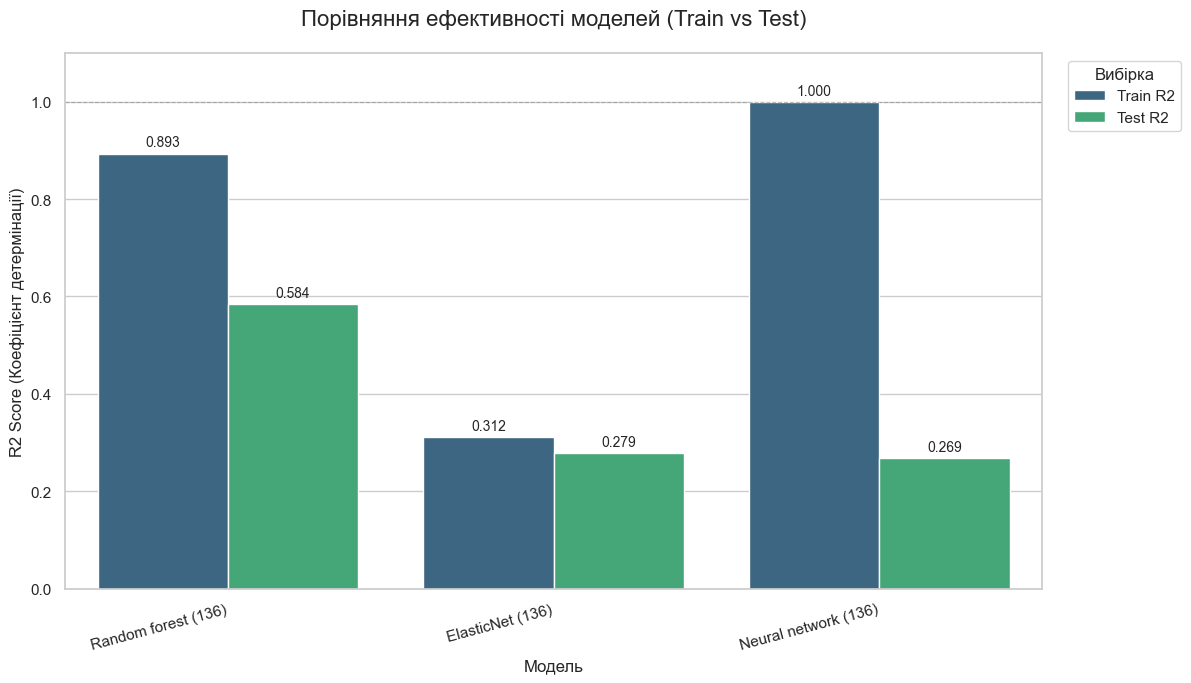

In [19]:
comparison_plot(results)

In [20]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.01617, learning_rate_init=0.0001074, hidden_layer_sizes=(30,))

Аналіз компонент PCA: 100%|██████████| 50/50 [07:13<00:00,  8.67s/it]


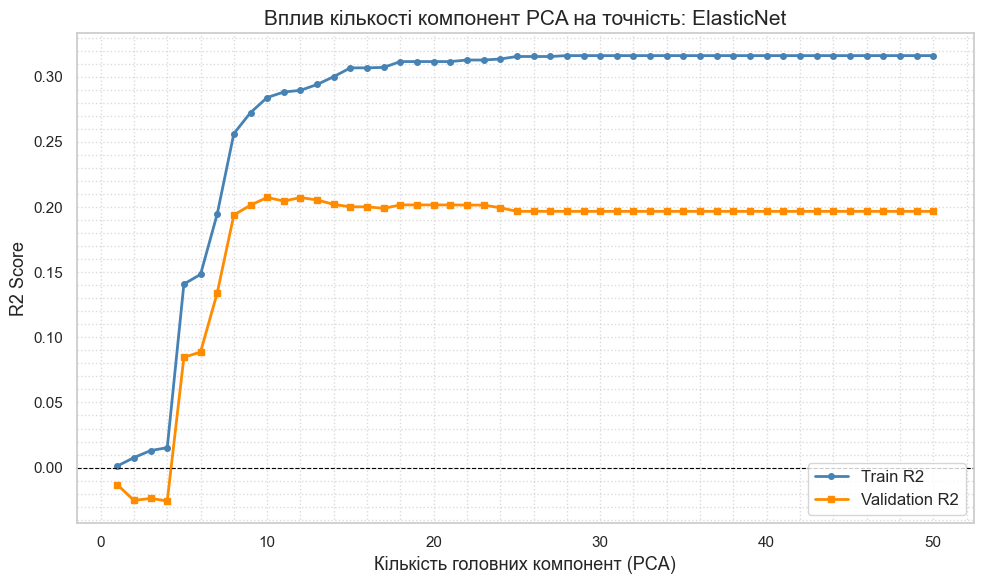

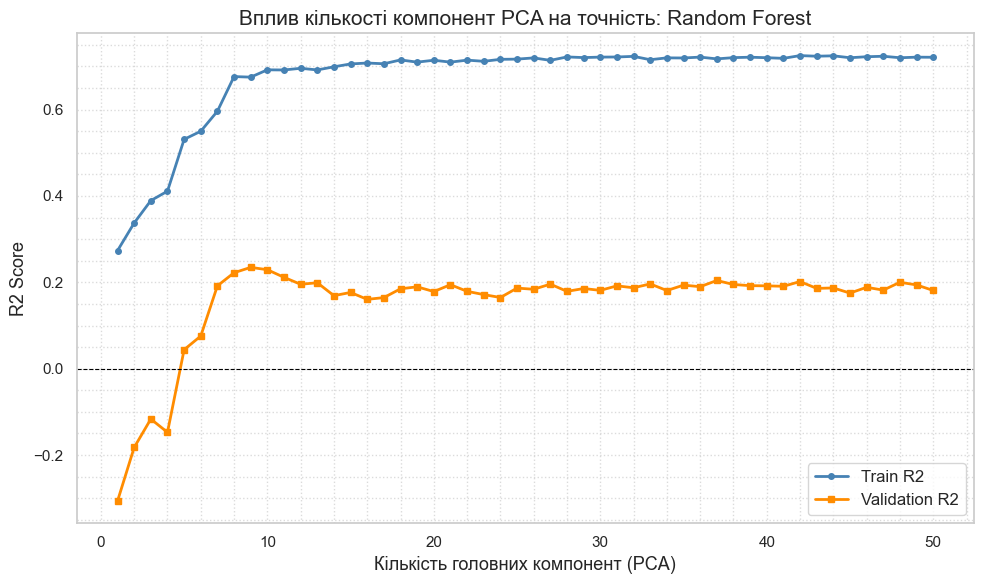

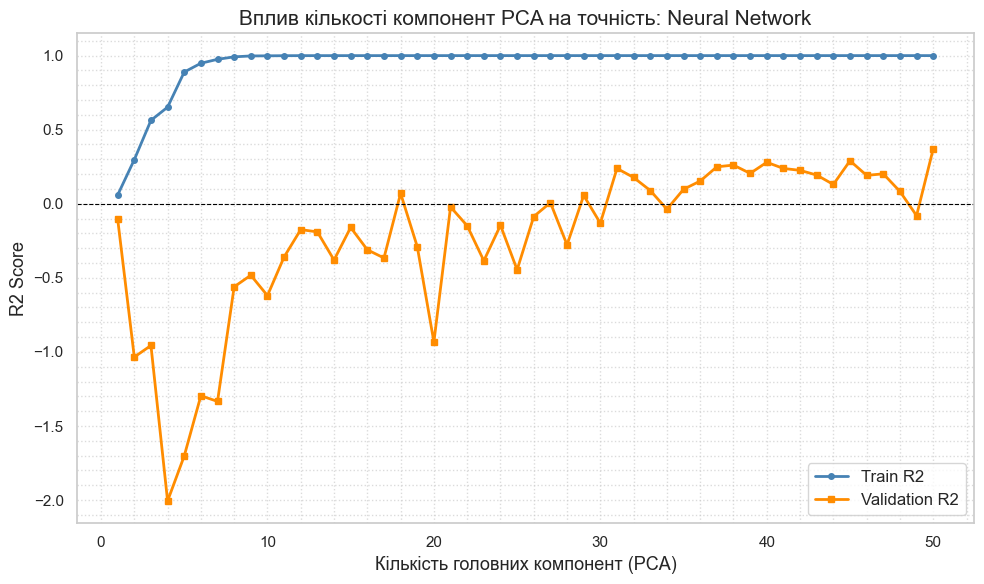

In [21]:
n_components_range = range(1, 51, 1)

scores = {
    'ElasticNet': {'train': [], 'val': []},
    'Random Forest': {'train': [], 'val': []},
    'Neural Network': {'train': [], 'val': []}
}

models = {
    'ElasticNet': elastic,
    'Random Forest': rf,
    'Neural Network': nn
}

for n in tqdm(n_components_range, desc="Аналіз компонент PCA"):

    for name, model in models.items():

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n)),
            ('model', model)
        ])

        cv_scores = cross_validate(
            estimator=pipe,
            X=x_train,
            y=y_train,
            cv=gkf,
            scoring='r2',
            return_train_score=True,
            groups=groups_train
        )

        r2_train = cv_scores['train_score'].mean()
        r2_val = cv_scores['test_score'].mean()

        scores[name]['train'].append(r2_train)
        scores[name]['val'].append(r2_val)

sns.set_theme(style="whitegrid")

for name in models.keys():
    plt.figure(figsize=(10, 6))

    plt.plot(n_components_range, scores[name]['train'],
             marker='o', markersize=4, label='Train R2', color='steelblue', linewidth=2)
    plt.plot(n_components_range, scores[name]['val'],
             marker='s', markersize=4, label='Validation R2', color='darkorange', linewidth=2)

    plt.title(f'Вплив кількості компонент PCA на точність: {name}', fontsize=15)
    plt.xlabel('Кількість головних компонент (PCA)', fontsize=13)
    plt.ylabel('R2 Score', fontsize=13)

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.minorticks_on()

    plt.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

In [22]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.01617, learning_rate_init=0.0001074, hidden_layer_sizes=(30,))

In [24]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('model', rf)
])

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=9)),
    ('model', elastic)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=18)),
    ('model', nn)
])

results_pca = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic_pca, r2_test_elastic_pca = fit_and_evaluate(elastic_pipe, x_train, y_train, x_test, y_test)
r2_train_rf_pca, r2_test_rf_pca = fit_and_evaluate(rf_pipe, x_train, y_train, x_test, y_test)
r2_train_nn_pca, r2_test_nn_pca = fit_and_evaluate(nn_pipe, x_train, y_train, x_test, y_test)

results_pca.loc[0] = ['ElasticNet PCA (10)', r2_train_elastic_pca, r2_test_elastic_pca]
results_pca.loc[1] = ['Random forest PCA (9)', r2_train_rf_pca, r2_test_rf_pca]
results_pca.loc[2] = ['Neural network PCA (18)', r2_train_nn_pca, r2_test_nn_pca]

results_pca

,Model,Train R2,Test R2
0,ElasticNet PCA (10),0.268033,0.213151
1,Random forest PCA (9),0.708141,0.345060
2,Neural network PCA (18),0.999803,-0.018542


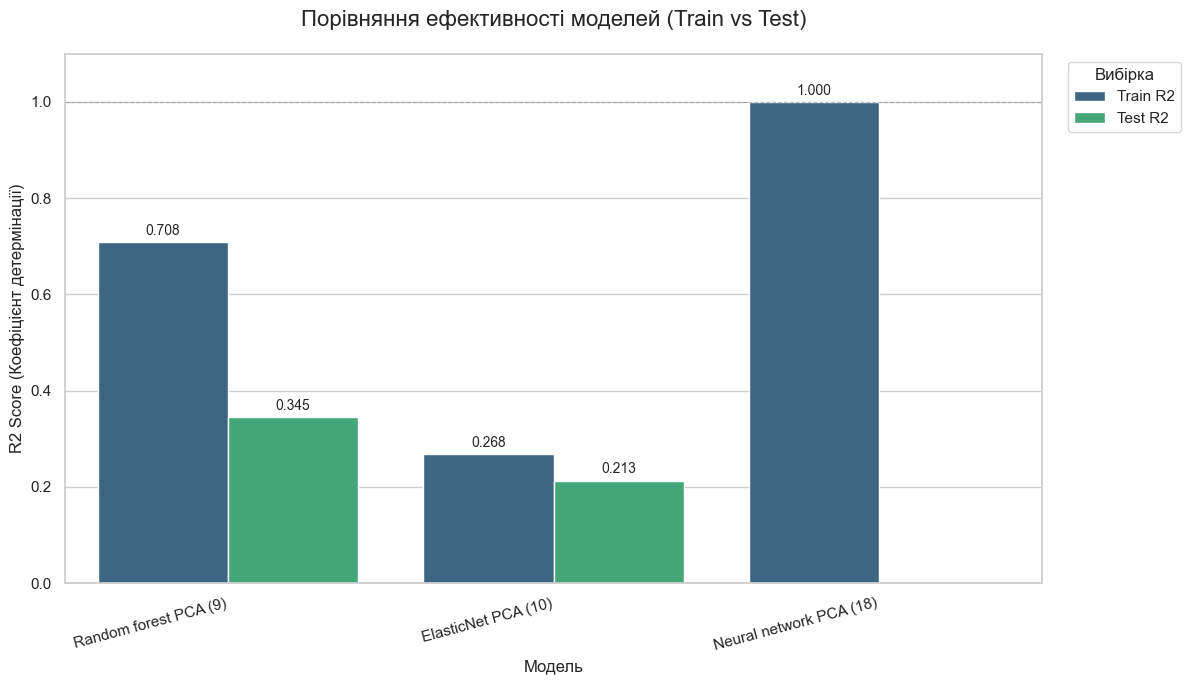

In [25]:
comparison_plot(results_pca)

Аналіз відібраних ознак: 100%|██████████| 50/50 [11:49<00:00, 14.20s/it]


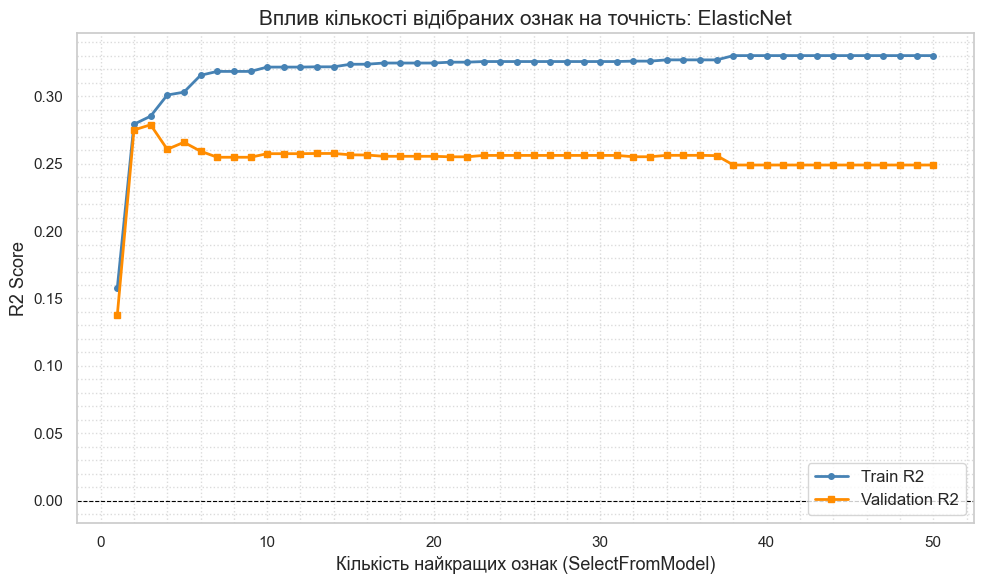

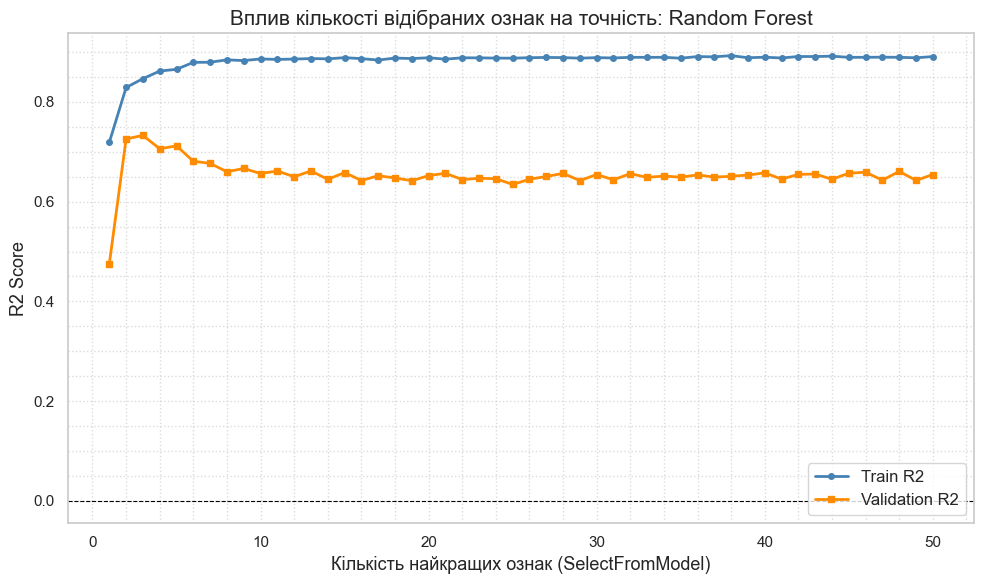

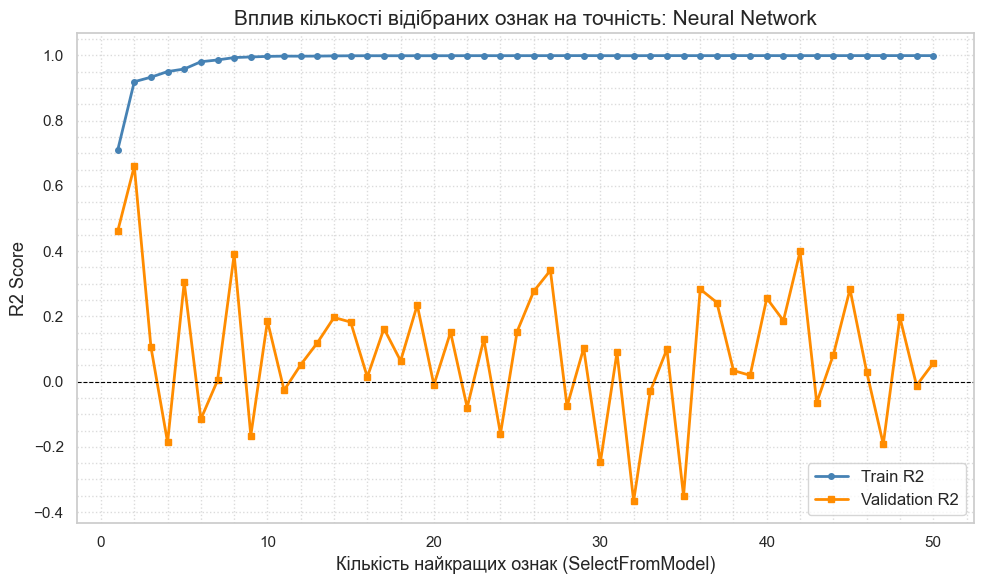

In [26]:
n_features_range = range(1, 51, 1)

scores = {
    'ElasticNet': {'train': [], 'val': []},
    'Random Forest': {'train': [], 'val': []},
    'Neural Network': {'train': [], 'val': []}
}

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)

models = {
    'ElasticNet': elastic,
    'Random Forest': rf,
    'Neural Network': nn
}

for n in tqdm(n_features_range, desc="Аналіз відібраних ознак"):

    for name, model in models.items():

        steps = [
            ('imputer', SimpleImputer(strategy='median'))
        ]

        if name != 'Random Forest':
            steps.append(('scaler', StandardScaler()))

        steps.append(('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=n)))

        steps.append(('model', model))

        pipe = Pipeline(steps)

        cv_scores = cross_validate(
            estimator=pipe,
            X=x_train,
            y=y_train,
            cv=gkf,
            scoring='r2',
            return_train_score=True,
            groups=groups_train
        )

        r2_train = cv_scores['train_score'].mean()
        r2_val = cv_scores['test_score'].mean()

        scores[name]['train'].append(r2_train)
        scores[name]['val'].append(r2_val)

sns.set_theme(style="whitegrid")

for name in models.keys():
    plt.figure(figsize=(10, 6))

    plt.plot(n_features_range, scores[name]['train'],
             marker='o', markersize=4, label='Train R2', color='steelblue', linewidth=2)
    plt.plot(n_features_range, scores[name]['val'],
             marker='s', markersize=4, label='Validation R2', color='darkorange', linewidth=2)

    plt.title(f'Вплив кількості відібраних ознак на точність: {name}', fontsize=15)
    plt.xlabel('Кількість найкращих ознак (SelectFromModel)', fontsize=13)
    plt.ylabel('R2 Score', fontsize=13)

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.minorticks_on()
    plt.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

In [27]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.01617, learning_rate_init=0.0001074, hidden_layer_sizes=(30,))

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=5)),
    ('model', elastic)
])

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=5)),
    ('model', rf)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=8)),
    ('model', nn)
])

In [47]:
imputer_rf = SimpleImputer(strategy='median')
x_train_imputed = pd.DataFrame(imputer_rf.fit_transform(x_train), columns=x_train.columns)

rf_selector.fit(x_train_imputed, y_train)

selector = SelectFromModel(
    rf_selector,
    threshold=-np.inf,
    max_features=10,
    prefit=True
)
selector.set_output(transform="pandas")

x_train_sel = selector.transform(x_train)
x_test_sel = selector.transform(x_test)

results_selected = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(elastic_pipe, x_train_sel, y_train, x_test_sel, y_test)
r2_train_rf, r2_test_rf = fit_and_evaluate(rf_pipe, x_train_sel, y_train, x_test_sel, y_test)
r2_train_nn, r2_test_nn = fit_and_evaluate(nn_pipe, x_train_sel, y_train, x_test_sel, y_test)

results_selected.loc[0] = ['ElasticNet Selected (5)', r2_train_elastic, r2_test_elastic]
results_selected.loc[1] = ['Random forest Selected (5)', r2_train_rf, r2_test_rf]
results_selected.loc[2] = ['Neural network Selected (8)', r2_train_nn, r2_test_nn]
results_selected

C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


,Model,Train R2,Test R2
0,ElasticNet Selected (5),0.309053,0.272997
1,Random forest Selected (5),0.892562,0.614260
2,Neural network Selected (8),0.994374,0.304016


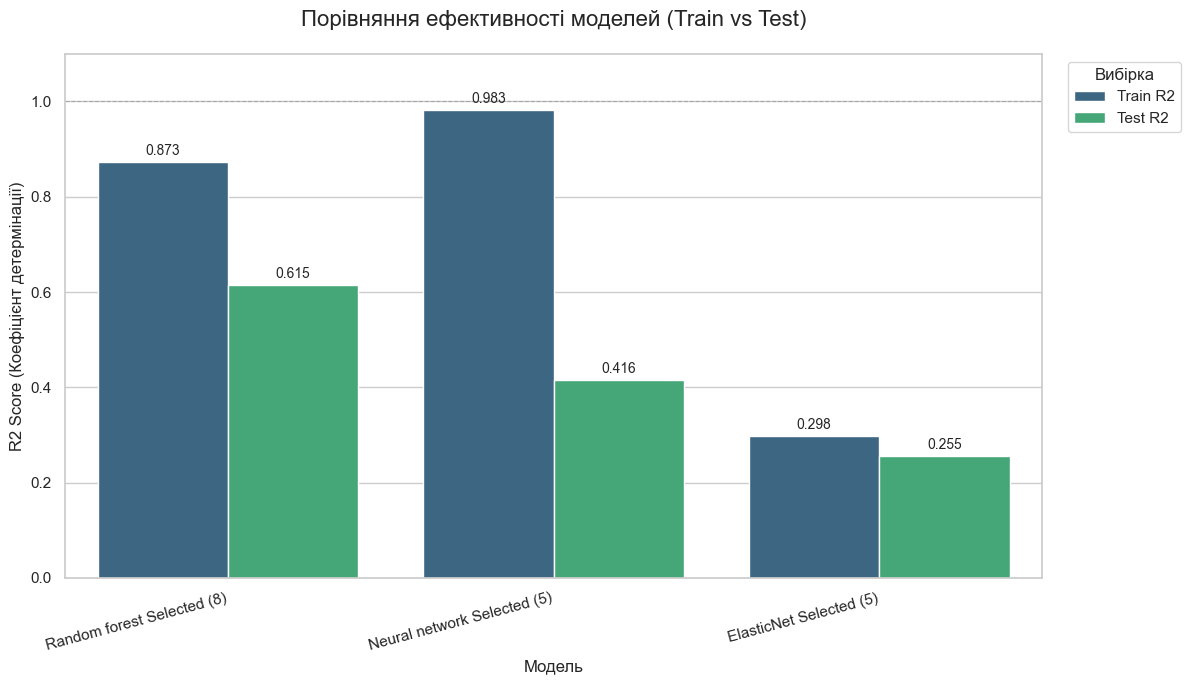

In [29]:
comparison_plot(results_selected)

In [30]:
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)

imputer_rfecv = SimpleImputer(strategy='median')
imputer_rfecv.set_output(transform="pandas")
x_train_imputed = imputer_rfecv.fit_transform(x_train)

rfecv = RFECV(
    estimator=rf_selector,
    step=1,
    cv=gkf,
    scoring='r2',
    min_features_to_select=5
)

rfecv.fit(x_train_imputed, y_train, groups=groups_train)

selected_features = x_train_imputed.columns[rfecv.support_]
print(f"Оптимальна кількість ознак: {rfecv.n_features_}")
print(selected_features.tolist())

Оптимальна кількість ознак: 5
['Рефрактометрія без циклоплегії Sphera', 'Рефрактометрія без циклоплегії Cylynder', 'Рефрактометрія циклоплегія Sphera', 'Рефрактометрія циклоплегія Cylynder', 'Axial length (mm)']


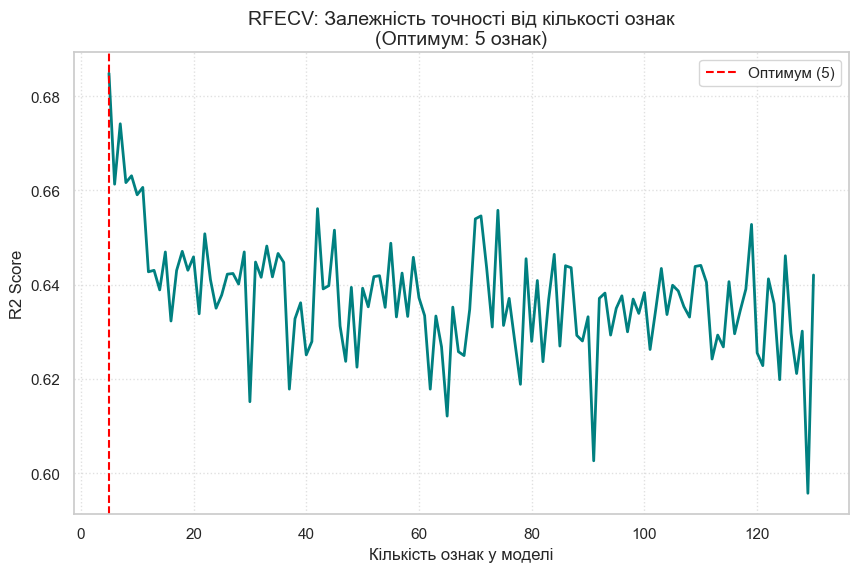

In [31]:
min_features = 5
plt.figure(figsize=(10, 6))
plt.xlabel("Кількість ознак у моделі")
plt.ylabel("R2 Score")

scores = rfecv.cv_results_['mean_test_score']
x_axis = range(min_features, len(scores) + min_features)
plt.plot(x_axis, scores, color='teal', linewidth=2)

plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Оптимум ({rfecv.n_features_})')

plt.title(f"RFECV: Залежність точності від кількості ознак\n(Оптимум: {rfecv.n_features_} ознак)", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [32]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.01617, learning_rate_init=0.0001074, hidden_layer_sizes=(30,))

In [33]:
features_rfe = ['Рефрактометрія без циклоплегії Sphera', 'Рефрактометрія без циклоплегії Cylynder', 'Рефрактометрія циклоплегія Sphera', 'Рефрактометрія циклоплегія Cylynder', 'Axial length (mm)']

x_train_rfe = x_train.loc[:, features_rfe]
x_test_rfe = x_test.loc[:, features_rfe]
num_features = len(features_rfe)

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', elastic)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

results_rfe = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic_rfe, r2_test_elastic_rfe = fit_and_evaluate(elastic_pipe, x_train_rfe, y_train, x_test_rfe, y_test)
r2_train_rf_rfe, r2_test_rf_rfe = fit_and_evaluate(rf_pipe, x_train_rfe, y_train, x_test_rfe, y_test)
r2_train_nn_rfe, r2_test_nn_rfe = fit_and_evaluate(nn_pipe, x_train_rfe, y_train, x_test_rfe, y_test)

results_rfe.loc[0] = [f'ElasticNet RFE ({num_features})', r2_train_elastic_rfe, r2_test_elastic_rfe]
results_rfe.loc[1] = [f'Random forest RFE ({num_features})', r2_train_rf_rfe, r2_test_rf_rfe]
results_rfe.loc[2] = [f'Neural network RFE ({num_features})', r2_train_nn_rfe, r2_test_nn_rfe]

results_rfe

,Model,Train R2,Test R2
0,ElasticNet RFE (5),0.298068,0.254652
1,Random forest RFE (5),0.872794,0.614516
2,Neural network RFE (5),0.945454,0.589836


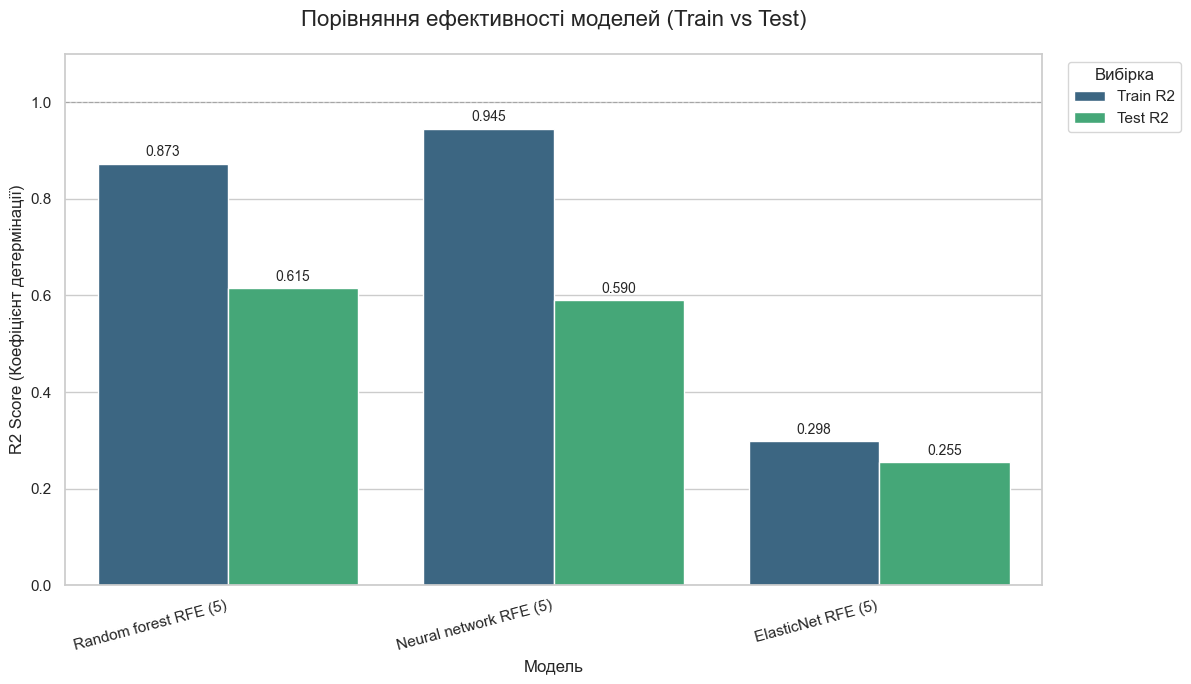

In [34]:
comparison_plot(results_rfe)

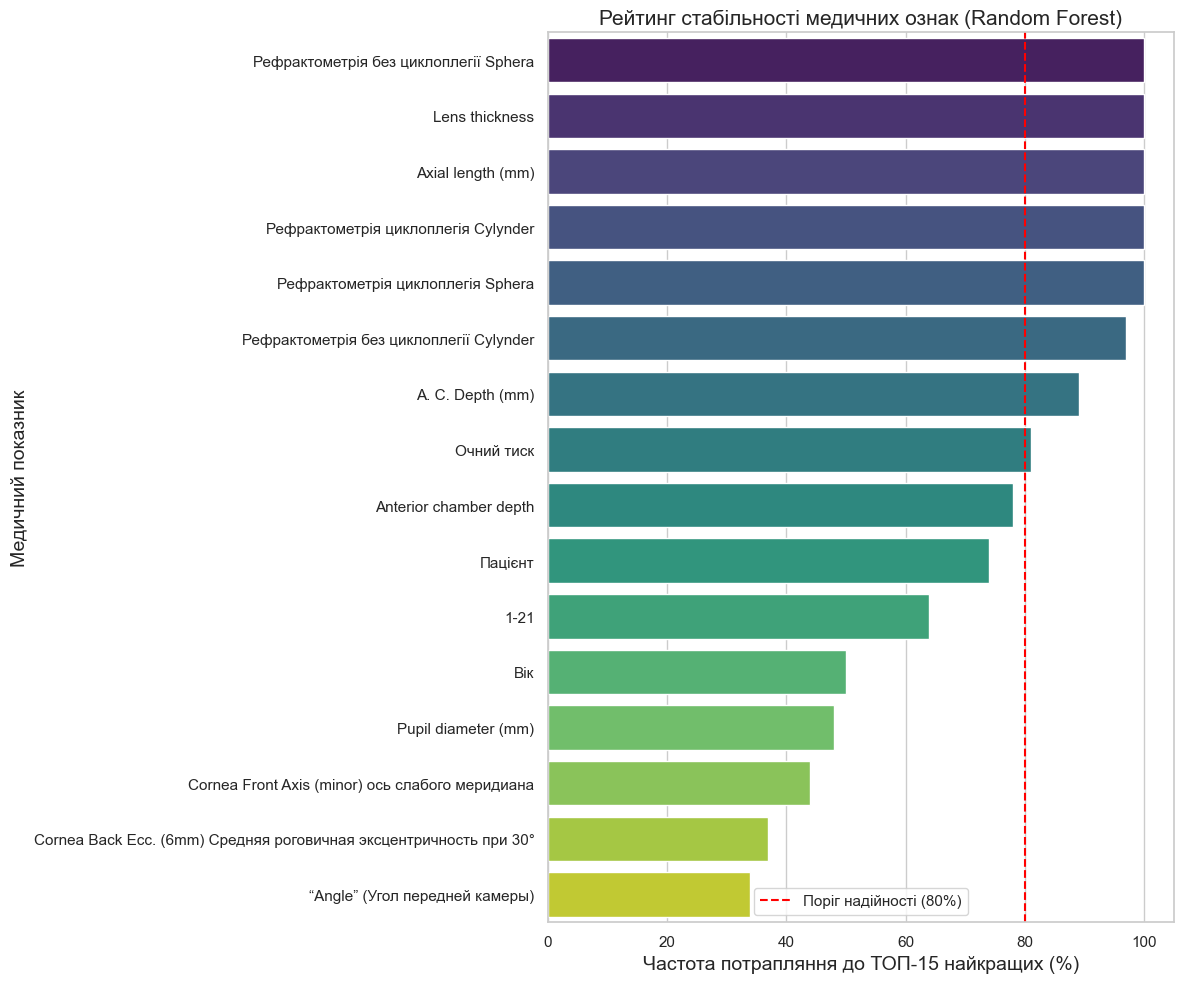

In [35]:
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)

feature_names = x.columns
n_iterations = 100
top_n_features = 15
feature_counter = Counter()

for i in range(n_iterations):
    x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(
        x, y, test_size=0.2, random_state=i
    )

    imputer = SimpleImputer(strategy='median')
    imputer.set_output(transform="pandas")
    x_train_imputed = imputer.fit_transform(x_train_split)

    rf_selector.fit(x_train_imputed, y_train_split)

    selector = SelectFromModel(
        rf_selector,
        threshold=-np.inf,
        max_features=top_n_features,
        prefit=True
    )

    selected_indices = selector.get_support(indices=True)
    selected_names = feature_names[selected_indices]
    feature_counter.update(selected_names)

stability_df = pd.DataFrame.from_dict(feature_counter, orient='index', columns=['Кількість виборів'])
stability_df['Стабільність (%)'] = (stability_df['Кількість виборів'] / n_iterations) * 100
stability_df = stability_df.sort_values(by='Стабільність (%)', ascending=False)

plt.figure(figsize=(12, 10))
plot_data = stability_df[stability_df['Стабільність (%)'] >= 30]

sns.barplot(
    x=plot_data['Стабільність (%)'],
    y=plot_data.index,
    hue=plot_data.index,
    palette='viridis',
    legend=False
)

plt.title('Рейтинг стабільності медичних ознак (Random Forest)', fontsize=15)
plt.xlabel(f'Частота потрапляння до ТОП-{top_n_features} найкращих (%)', fontsize=14)
plt.ylabel('Медичний показник', fontsize=14)
plt.axvline(x=80, color='red', linestyle='--', label='Поріг надійності (80%)')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
stability_df

,Кількість виборів,Стабільність (%)
Рефрактометрія без циклоплегії Sphera,100,100.0
Lens thickness,100,100.0
Axial length (mm),100,100.0
Рефрактометрія циклоплегія Cylynder,100,100.0
Рефрактометрія циклоплегія Sphera,100,100.0
...,...,...
1-3,1,1.0
Cornea Front Rmin (mm) наименьшая Кривизна Роговицы (mm),1,1.0
1-7,1,1.0
1-25,1,1.0


In [37]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.01617, learning_rate_init=0.0001074, hidden_layer_sizes=(30,))

In [38]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', elastic)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

In [53]:
stable_features = stability_df.index[:8].tolist()
x_train_stable = x_train[stable_features]
x_test_stable = x_test[stable_features]

results_stable = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(
    elastic_pipe, x_train_stable, y_train, x_test_stable, y_test
)
r2_train_rf, r2_test_rf = fit_and_evaluate(
    rf_pipe, x_train_stable, y_train, x_test_stable, y_test
)
r2_train_nn, r2_test_nn = fit_and_evaluate(
    nn_pipe, x_train_stable, y_train, x_test_stable, y_test
)

results_stable.loc[0] = ['ElasticNet Stable (8)', r2_train_elastic, r2_test_elastic]
results_stable.loc[1] = ['Random forest Stable (8)', r2_train_rf, r2_test_rf]
results_stable.loc[2] = ['Neural network Stable (8)', r2_train_nn, r2_test_nn]
results_stable

,Model,Train R2,Test R2
0,ElasticNet Stable (8),0.308680,0.273316
1,Random forest Stable (8),0.887397,0.628332
2,Neural network Stable (8),0.990896,0.449940


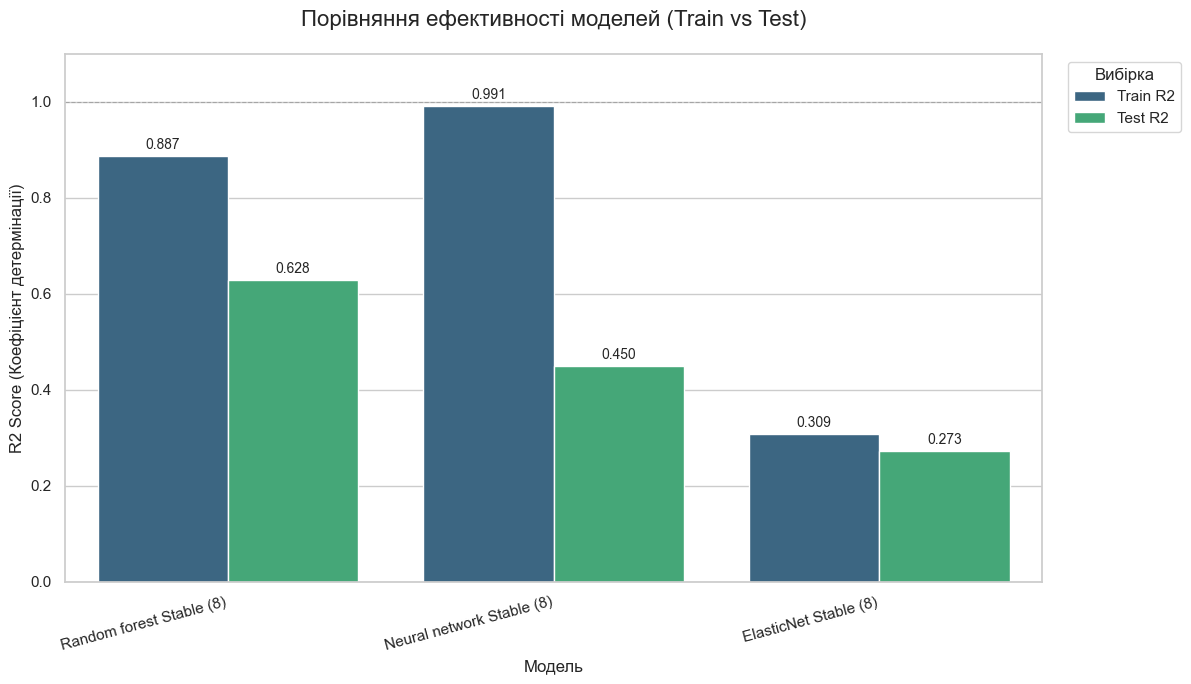

In [42]:
comparison_plot(results_stable)

In [50]:
results_full = pd.concat([results, results_pca, results_rfe, results_stable], axis=0)
results_full['Перенавчання'] = results_full['Train R2'] - results_full['Test R2']
results_full

,Model,Train R2,Test R2,Перенавчання
0,ElasticNet (136),0.312069,0.278863,0.033206
1,Random forest (136),0.893426,0.584040,0.309387
2,Neural network (136),0.999715,0.269042,0.730673
0,ElasticNet PCA (10),0.268033,0.213151,0.054882
1,Random forest PCA (9),0.708141,0.345060,0.363081
2,Neural network PCA (18),0.999803,-0.018542,1.018345
0,ElasticNet RFE (5),0.298068,0.254652,0.043416
1,Random forest RFE (5),0.872794,0.614516,0.258279
2,Neural network RFE (5),0.945454,0.589836,0.355618
0,ElasticNet Stable (8),0.308680,0.273316,0.035364


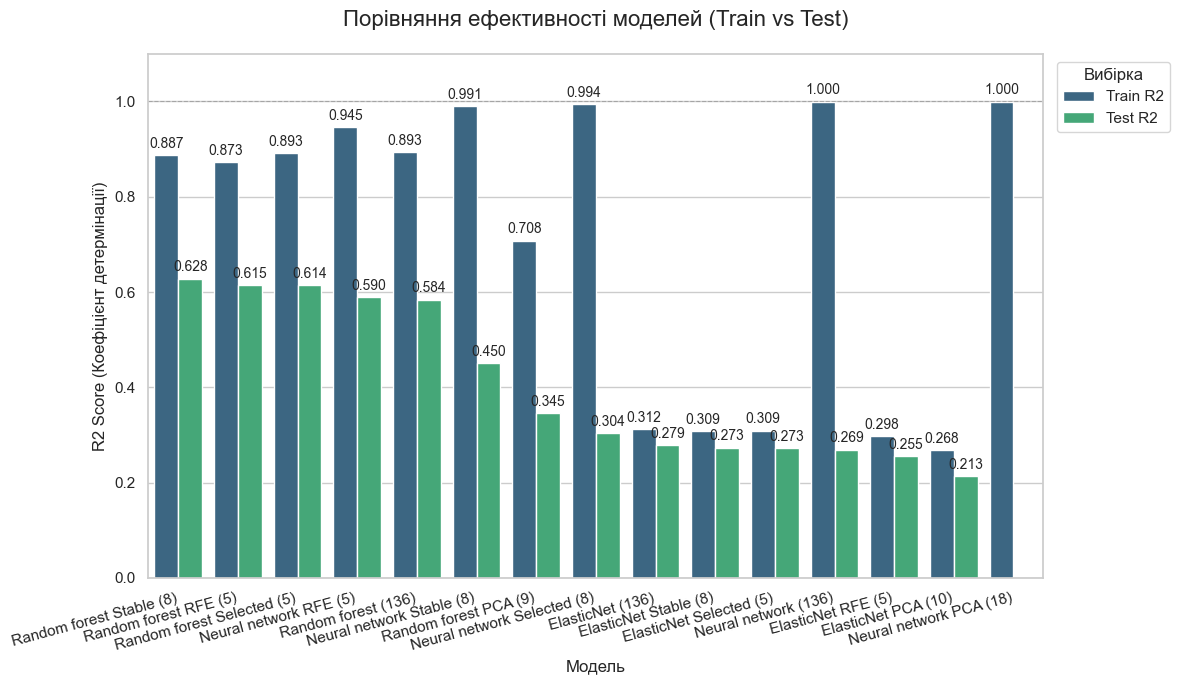

In [49]:
comparison_plot(results_full)

In [ ]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', max_depth=10)
nn = MLPRegressor(activation='tanh', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.0726, learning_rate_init=0.0012, hidden_layer_sizes=(30, 15))

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

log_target_rf_pipe = TransformedTargetRegressor(
    regressor=rf_pipe, func=np.log1p, inverse_func=np.expm1
)

log_target_nn_pipe = TransformedTargetRegressor(
    regressor=nn_pipe, func=np.log1p, inverse_func=np.expm1
)

In [ ]:
x_train_rfe = x_train.loc[:, features_rfe]
x_test_rfe = x_test.loc[:, features_rfe]

log_target_rf_pipe.fit(x_train_rfe, y_train)
y_pred_test_rf = log_target_rf_pipe.predict(x_test_rfe)

r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

log_target_nn_pipe.fit(x_train_stable, y_train)
y_pred_test_nn = nn.predict(x_test_rfe)

r2_test_nn = r2_score(y_test, y_pred_test_nn)
mae_test_nn = mean_absolute_error(y_test, y_pred_test_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))

results_test_stable = pd.DataFrame(columns=['Model', 'Test R2', 'MAE', "RMSE"])

results_test_stable.loc[0] = ['Random Forest RFE (10)', r2_test_rf, mae_test_rf, rmse_test_rf]
results_test_stable.loc[1] = ['Neural Network RFE (10)', r2_test_nn, mae_test_nn, rmse_test_nn]

In [ ]:
rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=50)
rf_selector.fit(x_train_scaled, y_train)

selector = SelectFromModel(rf_selector, threshold=-np.inf, max_features=17, prefit=True)
selector.set_output(transform="pandas")

x_train_sel = selector.transform(x_train_scaled)
x_test_sel = selector.transform(x_test_scaled)

rf.fit(x_train_sel, y_train)
y_pred_test_rf = rf.predict(x_test_sel)

r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

nn.fit(x_train_sel, y_train)
y_pred_test_nn = nn.predict(x_test_sel)

r2_test_nn = r2_score(y_test, y_pred_test_nn)
mae_test_nn = mean_absolute_error(y_test, y_pred_test_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))

results_test_selected = pd.DataFrame(columns=['Model', 'Test R2', 'MAE', "RMSE"])

results_test_selected.loc[0] = ['Random Forest Selected (17)', r2_test_rf, mae_test_rf, rmse_test_rf]
results_test_selected.loc[1] = ['Neural Network Selected (17)', r2_test_nn, mae_test_nn, rmse_test_nn]

In [ ]:
results_test = pd.concat([results_test_stable, results_test_selected], axis=0)
results_test

In [ ]:
res_sorted = results_test.sort_values('Test R2', ascending=False)

df_melted = res_sorted.melt(id_vars='Model',
                            value_vars=['Test R2', 'MAE', 'RMSE'],
                            var_name='Metric',
                            value_name='Score')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=11)

plt.title('Порівняння фінальних моделей на незалежній тестовій вибірці', fontsize=16, pad=20)
plt.ylabel('Значення метрики', fontsize=12)
plt.xlabel('Модель', fontsize=12)

plt.ylim(0, 1.1)

plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.legend(title='Метрика', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
rf.fit(x_train_stable, y_train)
y_pred_test_rf = rf.predict(x_test_stable)
residuals = y_test - y_pred_test_rf

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_test_rf, alpha=0.7, color='dodgerblue', edgecolor='k')
min_val = min(y_test.min(), y_pred_test_rf.min())
max_val = max(y_test.max(), y_pred_test_rf.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ідеальний збіг')
axes[0].set_title('Прогноз vs Реальна гострота зору', fontsize=14, pad=10)
axes[0].set_xlabel('Реальні значення (y_test)', fontsize=12)
axes[0].set_ylabel('Прогнозовані значення (y_pred)', fontsize=12)
axes[0].legend(fontsize=11)

axes[1].scatter(y_pred_test, residuals, alpha=0.7, color='darkorange', edgecolor='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Нульова помилка')
axes[1].set_title('Аналіз залишків (Residual Plot)', fontsize=14, pad=10)
axes[1].set_xlabel('Прогнозовані значення', fontsize=12)
axes[1].set_ylabel('Залишки (Реальність - Прогноз)', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()